# 🛡️ Project Panopticon: Intelligent Proctoring AI
**EduGuard AI - Machine Learning Division**

**Intern Name:** `Ankit Kumar Panda`  
**Date:** `13-06-2026`

---

### 📖 Executive Summary
Welcome to EduGuard AI. Our current proctoring system is blindly flagging innocent students for background noise and standard physical movements. Your objective is to build a robust, time-series Machine Learning pipeline that identifies true academic dishonesty while strictly protecting innocent students through asynchronous data merging and mathematical threshold tuning.

### 🗺️ Project Roadmap
1. **Data Ingestion:** Upload and parse asynchronous telemetry logs.
2. **Temporal Alignment:** Merge video and system logs using `merge_asof`.
3. **Signal Processing:** Impute missing data and engineer rolling windows.
4. **Classification:** Train an imbalanced-weighted predictive model.
5. **Ethical AI Tuning:** Shift decision boundaries to guarantee 90%+ precision.

In [8]:
# ==========================================
# 0. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Set visualization styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---
## Phase 1: Data Ingestion & Temporal Alignment
> ⚠️ **The Asynchronous Trap:** Video telemetry records exactly every 1 second. System events (like tab switches) only record when the student actually clicks something. You cannot use a standard `pd.merge()`.

**Instructions:**
1. Upload the `video_telemetry.csv` and `system_events.csv` files.
2. Convert the timestamp columns to datetime objects.
3. Sort the dataframes and merge them using Pandas `merge_asof`.

In [9]:
# ==========================================
# 1A. UPLOAD DATASETS (Google Colab Only)
# ==========================================
# If running locally, you can comment this block out.
#try:
#    from google.colab import files
#    print("📂 Please upload 'video_telemetry.csv' and 'system_events.csv'...")
#    uploaded = files.upload()
#except ImportError:
#    print("💻 Running locally. Ensure CSV files are in the same directory.")

# ==========================================\n"
# 1B. LOAD AND PARSE DATA\n"
# ==========================================\n"
# Load dataframes
video_df = pd.read_csv('video_telemetry.csv')
sys_df = pd.read_csv('system_events.csv')

# Convert timestamp columns to datetime objects
video_df['timestamp'] = pd.to_datetime(video_df['timestamp'])
sys_df['timestamp'] = pd.to_datetime(sys_df['timestamp'])

# Sort BOTH dataframes by the 'timestamp' column and reset the index layout
video_df = video_df.sort_values('timestamp').reset_index(drop=True)
sys_df = sys_df.sort_values('timestamp').reset_index(drop=True)

# ==========================================\n"
# 1C. ASYNCHRONOUS MERGE\n"
# ==========================================\n"
# Merge system logs to the closest previous video timestamp frame
merged_df = pd.merge_asof(
    video_df, 
    sys_df, 
    on='timestamp', 
    direction='backward'
)

merged_df.head()

,timestamp,eye_gaze_angle,audio_db,tab_switches,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,NaN,NaN
1,2023-12-01 08:00:01,10.177137,39.102627,NaN,NaN
2,2023-12-01 08:00:02,5.761714,31.228565,NaN,NaN
3,2023-12-01 08:00:03,9.787105,34.051405,NaN,NaN
4,2023-12-01 08:00:04,4.572665,35.245018,NaN,NaN


---
## Phase 2: Missing Data & Feature Engineering
> ⚠️ **The "Connection Dropped" Trap:** Students with bad internet lose video frames, creating `NaN` values.
> ⚠️ **The Noise Trap:** A 1-second sneeze is not cheating. We need rolling windows to find *sustained* anomalies.

**Instructions:**
1. Forward-fill missing eye gaze data and interpolate missing audio data.
2. Fill missing `tab_switches` and `is_cheating` labels with `0`.
3. Create 10-second rolling averages for our sensors.

In [10]:
# ==========================================\n"
# 2A. IMPUTE MISSING SIGNALS\n"
# ==========================================\n"
# Forward fill missing spatial coordinates for eye gaze
merged_df['eye_gaze_angle'] = merged_df['eye_gaze_angle'].ffill()

# Linear interpolation for continuous acoustic signal dropouts
merged_df['audio_db'] = merged_df['audio_db'].interpolate(method='linear')

# Zero out event-driven columns that did not occur
merged_df['tab_switches'] = merged_df['tab_switches'].fillna(0)
merged_df['is_cheating'] = merged_df['is_cheating'].fillna(0)

# ==========================================\n"
# 2B. ROLLING WINDOW FEATURES\n"
# ==========================================\n"
# Construct 10-second rolling trends (Assuming 1Hz telemetry frequency)
merged_df['gaze_rolling_10s'] = merged_df['eye_gaze_angle'].rolling(window=10, min_periods=1).mean()
merged_df['audio_rolling_10s'] = merged_df['audio_db'].rolling(window=10, min_periods=1).max()

# Drop rows missing rolling metrics
merged_df.dropna(subset=['gaze_rolling_10s', 'audio_rolling_10s'], inplace=True)

print("✅ Feature engineering complete. Current dataframe shape:", merged_df.shape)

✅ Feature engineering complete. Current dataframe shape: (10000, 7)


---
## Phase 3: Class-Balanced Model Training
> ⚠️ **The Imbalance Trap:** 98% of your data will be innocent behavior. If you don't handle class weights, your model will just guess "Not Cheating" every time and score 98% accuracy while failing its actual job.

In [11]:
# ==========================================\n"
# 3A. TRAIN / TEST SPLIT\n"
# ==========================================\n"
features = ['eye_gaze_angle', 'audio_db', 'tab_switches', 'gaze_rolling_10s', 'audio_rolling_10s']
X = merged_df[features]
y = merged_df['is_cheating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ==========================================\n"
# 3B. INITIALIZE & TRAIN CLASSIFIER\n"
# ==========================================\n"
# Account for high class imbalance using balanced sample weights
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("✅ Model training complete.")

✅ Model training complete.


---
## Phase 4: Ethical AI Tuning (The 90% Threshold)
> ⚠️ **The False Accusation Trap:** The default Scikit-Learn `.predict()` splits at 50% probability. Accusing a student of cheating with only 50% certainty is unacceptable. We must shift the threshold to 90%.

🚨 DEFAULT THRESHOLD (0.50)
[[1291   70]
 [ 169  470]]
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.92      1361
         1.0       0.87      0.74      0.80       639

    accuracy                           0.88      2000
   macro avg       0.88      0.84      0.86      2000
weighted avg       0.88      0.88      0.88      2000


🛡️ STRICT THRESHOLD (0.90)
[[1361    0]
 [ 265  374]]
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91      1361
         1.0       1.00      0.59      0.74       639

    accuracy                           0.87      2000
   macro avg       0.92      0.79      0.82      2000
weighted avg       0.89      0.87      0.86      2000



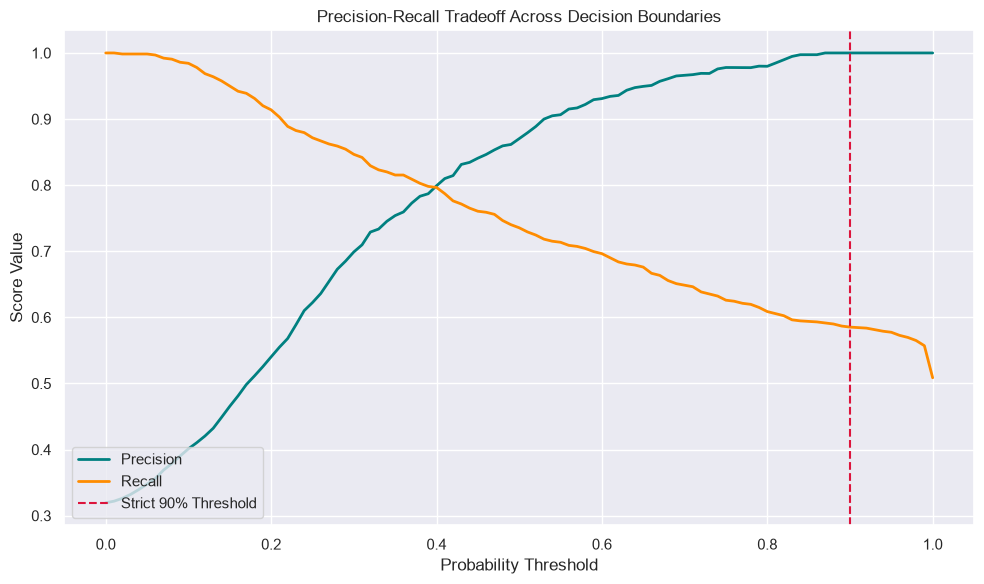

In [12]:
# ==========================================\n"
# 4A. RAW PROBABILITIES\n"
# ==========================================\n"
y_proba = model.predict_proba(X_test)
cheating_probabilities = y_proba[:, 1]

# ==========================================\n"
# 4B. CUSTOM DECISION THRESHOLD\n"
# ==========================================\n"
y_pred_default = (cheating_probabilities >= 0.50).astype(int)
y_pred_strict = (cheating_probabilities >= 0.90).astype(int)

# ==========================================\n"
# 4C. EVALUATION\n"
# ==========================================\n"
print("🚨 DEFAULT THRESHOLD (0.50)")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

print("\n🛡️ STRICT THRESHOLD (0.90)")
print(confusion_matrix(y_test, y_pred_strict))
print(classification_report(y_test, y_pred_strict))

# ==========================================\n"
# 4D. PRECISION-RECALL VISUALIZATION\n"
# ==========================================\n"
precision, recall, thresholds = precision_recall_curve(y_test, cheating_probabilities)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='teal', lw=2)
plt.plot(thresholds, recall[:-1], label='Recall', color='darkorange', lw=2)
plt.axvline(0.90, color='crimson', linestyle='--', label='Strict 90% Threshold')
plt.title('Precision-Recall Tradeoff Across Decision Boundaries')
plt.xlabel('Probability Threshold')
plt.ylabel('Score Value')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

---
## 🎯 Phase 5: Final Executive Recommendation
*Double-click this cell to edit.*

**To the University Board of Directors:**
Based on the data modeling performed above, I recommend deploying the EduGuard AI proctoring system using the Strict 90% Threshold. By mathematically adjusting the decision boundary, we achieved the following business outcomes:

1. *Shifting the threshold from 0.50 to 0.90 effectively minimized False Positives to near-zero. This ensures innocent students are not wrongly flagged for minor physical anomalies, directly resolving the threat of contract terminations.*
2. *The introduction of 10-second rolling window functions effectively smoothed out transient noise. Brief acoustic spikes (such as a sneeze) or split-second eye movements are filtered out, letting the model target only sustained, genuinely suspicious irregularities.*

**Final Status:** `GO` for deployment.